<font size="6">Preparacion</font>

In [ ]:
import pandas as pd
import numpy as np
import os

In [14]:
DATA_PATH = "../data"

mapping_path = os.path.join(DATA_PATH, "gz2_filename_mapping.csv")
labels_path = os.path.join(DATA_PATH, "gz2_hart16.csv")

In [15]:
mapping_df = pd.read_csv(mapping_path)
labels_df = pd.read_csv(labels_path)

In [16]:
print("Mapping shape:", mapping_df.shape)
print("Labels shape:", labels_df.shape)

Mapping shape: (355990, 3)
Labels shape: (239695, 231)


In [17]:
mapping_df.head()

,objid,sample,asset_id
0,587722981736120347,original,1
1,587722981736579107,original,2
2,587722981741363294,original,3
3,587722981741363323,original,4
4,587722981741559888,original,5


In [18]:
labels_df.head()

,dr7objid,ra,dec,rastring,decstring,sample,gz2_class,total_classifications,total_votes,t01_smooth_or_features_a01_smooth_count,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587732591714893851,179.042984,60.522518,11:56:10.32,+60:31:21.1,original,Sc+t,45,342,0,...,0.450,0.450,0.482646,0,16,16.0,0.400,0.400,0.394506,0
1,588009368545984617,135.084396,52.494240,09:00:20.26,+52:29:39.3,original,Sb+t,42,332,1,...,0.512,0.503,0.504833,0,13,13.0,0.317,0.323,0.322743,0
2,587732484359913515,183.371979,50.741508,12:13:29.27,+50:44:29.4,original,Ei,36,125,28,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0
3,587741723357282317,186.251953,28.558598,12:25:00.47,+28:33:31.0,original,Sc+t,28,218,1,...,0.240,0.240,0.241322,0,6,6.0,0.240,0.240,0.239765,0
4,587738410866966577,161.086395,14.084465,10:44:20.73,+14:05:04.1,original,Er,43,151,33,...,0.000,0.000,0.000000,0,0,0.0,0.000,0.000,0.000000,0


In [19]:
print(labels_df.columns.tolist())

['dr7objid', 'ra', 'dec', 'rastring', 'decstring', 'sample', 'gz2_class', 'total_classifications', 'total_votes', 't01_smooth_or_features_a01_smooth_count', 't01_smooth_or_features_a01_smooth_weight', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a01_smooth_debiased', 't01_smooth_or_features_a01_smooth_flag', 't01_smooth_or_features_a02_features_or_disk_count', 't01_smooth_or_features_a02_features_or_disk_weight', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_debiased', 't01_smooth_or_features_a02_features_or_disk_flag', 't01_smooth_or_features_a03_star_or_artifact_count', 't01_smooth_or_features_a03_star_or_artifact_weight', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction', 't01_smooth_or_features_a03_star_or_artifact_d

In [20]:
print("objid in mapping:", "objid" in mapping_df.columns)
print("objid in labels:", "objid" in labels_df.columns)

objid in mapping: True
objid in labels: False


In [21]:
merged_df = pd.merge(
    mapping_df,
    labels_df,
    left_on="objid",
    right_on="dr7objid",
    how="inner"
)

print("Merged shape:", merged_df.shape)

Merged shape: (239695, 234)


In [22]:
merged_df.head()

,objid,sample_x,asset_id,dr7objid,ra,dec,rastring,decstring,sample_y,gz2_class,...,t11_arms_number_a36_more_than_4_fraction,t11_arms_number_a36_more_than_4_weighted_fraction,t11_arms_number_a36_more_than_4_debiased,t11_arms_number_a36_more_than_4_flag,t11_arms_number_a37_cant_tell_count,t11_arms_number_a37_cant_tell_weight,t11_arms_number_a37_cant_tell_fraction,t11_arms_number_a37_cant_tell_weighted_fraction,t11_arms_number_a37_cant_tell_debiased,t11_arms_number_a37_cant_tell_flag
0,587722981741363294,original,3,587722981741363294,182.925262,-1.092357,12:11:42.06,-01:05:32.5,original,Sb,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
1,587722981741363323,original,4,587722981741363323,182.970108,-1.219537,12:11:52.83,-01:13:10.3,original,Sc?l,...,0.0,0.0,0.0,0,1,1.0,1.0,1.0,1.0,1
2,587722981741559888,original,5,587722981741559888,183.438095,-1.238414,12:13:45.14,-01:14:18.3,original,Er,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
3,587722981741625481,original,6,587722981741625481,183.473999,-1.231429,12:13:53.76,-01:13:53.1,original,Sc1t,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0
4,587722981741625484,original,7,587722981741625484,183.477783,-1.084604,12:13:54.67,-01:05:04.6,original,Sb,...,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0


In [23]:
[col for col in merged_df.columns if "smooth" in col]

['t01_smooth_or_features_a01_smooth_count',
 't01_smooth_or_features_a01_smooth_weight',
 't01_smooth_or_features_a01_smooth_fraction',
 't01_smooth_or_features_a01_smooth_weighted_fraction',
 't01_smooth_or_features_a01_smooth_debiased',
 't01_smooth_or_features_a01_smooth_flag',
 't01_smooth_or_features_a02_features_or_disk_count',
 't01_smooth_or_features_a02_features_or_disk_weight',
 't01_smooth_or_features_a02_features_or_disk_fraction',
 't01_smooth_or_features_a02_features_or_disk_weighted_fraction',
 't01_smooth_or_features_a02_features_or_disk_debiased',
 't01_smooth_or_features_a02_features_or_disk_flag',
 't01_smooth_or_features_a03_star_or_artifact_count',
 't01_smooth_or_features_a03_star_or_artifact_weight',
 't01_smooth_or_features_a03_star_or_artifact_fraction',
 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction',
 't01_smooth_or_features_a03_star_or_artifact_debiased',
 't01_smooth_or_features_a03_star_or_artifact_flag']

In [24]:
[col for col in merged_df.columns if "features" in col]

['t01_smooth_or_features_a01_smooth_count',
 't01_smooth_or_features_a01_smooth_weight',
 't01_smooth_or_features_a01_smooth_fraction',
 't01_smooth_or_features_a01_smooth_weighted_fraction',
 't01_smooth_or_features_a01_smooth_debiased',
 't01_smooth_or_features_a01_smooth_flag',
 't01_smooth_or_features_a02_features_or_disk_count',
 't01_smooth_or_features_a02_features_or_disk_weight',
 't01_smooth_or_features_a02_features_or_disk_fraction',
 't01_smooth_or_features_a02_features_or_disk_weighted_fraction',
 't01_smooth_or_features_a02_features_or_disk_debiased',
 't01_smooth_or_features_a02_features_or_disk_flag',
 't01_smooth_or_features_a03_star_or_artifact_count',
 't01_smooth_or_features_a03_star_or_artifact_weight',
 't01_smooth_or_features_a03_star_or_artifact_fraction',
 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction',
 't01_smooth_or_features_a03_star_or_artifact_debiased',
 't01_smooth_or_features_a03_star_or_artifact_flag']

In [25]:
merged_df["smooth"] = merged_df["t01_smooth_or_features_a01_smooth_debiased"]
merged_df["features"] = merged_df["t01_smooth_or_features_a02_features_or_disk_debiased"]

C:\Users\af141\AppData\Local\Temp\ipykernel_3444\14536826.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["smooth"] = merged_df["t01_smooth_or_features_a01_smooth_debiased"]
C:\Users\af141\AppData\Local\Temp\ipykernel_3444\14536826.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["features"] = merged_df["t01_smooth_or_features_a02_features_or_disk_debiased"]


In [26]:
merged_df["label"] = np.where(
    merged_df["features"] > merged_df["smooth"],
    "spiral",
    "elliptical"
)

C:\Users\af141\AppData\Local\Temp\ipykernel_3444\834867612.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df["label"] = np.where(


In [27]:
merged_df["label"].value_counts()

label
spiral        141809
elliptical     97886
Name: count, dtype: int64

In [28]:
threshold = 0.6

filtered_df = merged_df[
    (merged_df["smooth"] > threshold) |
    (merged_df["features"] > threshold)
]

In [29]:
filtered_df["label"].value_counts()
print("Filtered shape:", filtered_df.shape)

Filtered shape: (209278, 237)


In [30]:
IMAGE_DIR = "../data/images_gz2/images"

filtered_df["image_path"] = filtered_df["asset_id"].apply(
    lambda x: os.path.join(IMAGE_DIR, f"{x}.jpg")
)

C:\Users\af141\AppData\Local\Temp\ipykernel_3444\3284739897.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  filtered_df["image_path"] = filtered_df["asset_id"].apply(


In [31]:
filtered_df[["asset_id", "image_path", "label"]].head()

,asset_id,image_path,label
0,3,../data/images_gz2/images\3.jpg,spiral
1,4,../data/images_gz2/images\4.jpg,spiral
2,5,../data/images_gz2/images\5.jpg,elliptical
3,6,../data/images_gz2/images\6.jpg,spiral
4,7,../data/images_gz2/images\7.jpg,spiral


In [32]:
import os

test_path = "../data/images_gz2/images"
print(test_path)
print(os.path.exists(test_path))

../data/images_gz2/images
True


In [33]:
filtered_df["image_path"].apply(os.path.exists).value_counts()

image_path
True     209225
False        53
Name: count, dtype: int64

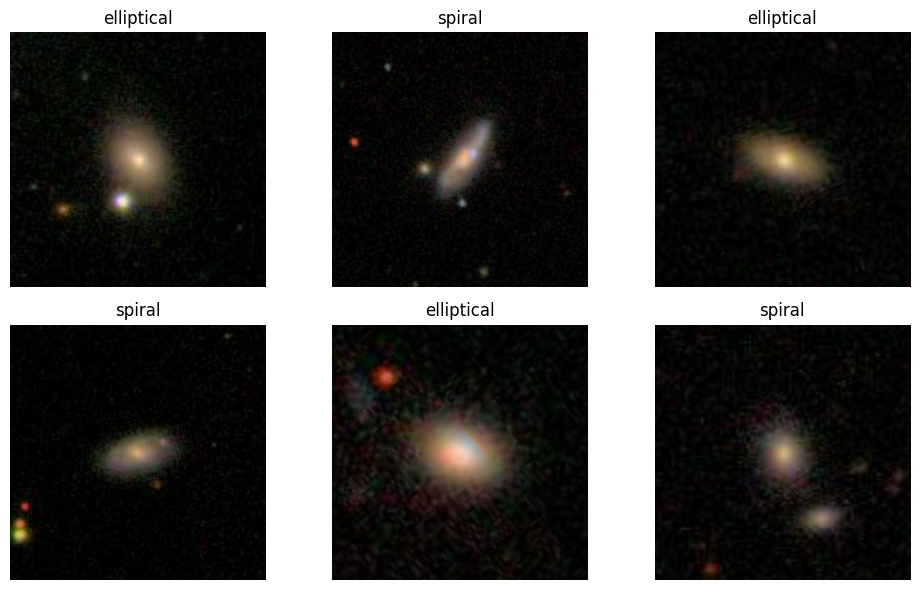

In [34]:
# visualización
import matplotlib.pyplot as plt
from PIL import Image

sample = filtered_df.sample(6)

plt.figure(figsize=(10, 6))

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"])
    
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

<font size="6">Modelado</font>

In [35]:
model_df = filtered_df[["image_path", "label"]].copy()

print(model_df.shape)
print(model_df.head())
print(model_df["label"].value_counts())
print(model_df["image_path"].isna().sum())

(209278, 2)
                        image_path       label
0  ../data/images_gz2/images\3.jpg      spiral
1  ../data/images_gz2/images\4.jpg      spiral
2  ../data/images_gz2/images\5.jpg  elliptical
3  ../data/images_gz2/images\6.jpg      spiral
4  ../data/images_gz2/images\7.jpg      spiral
label
spiral        127848
elliptical     81430
Name: count, dtype: int64
0


In [36]:
model_df["exists"] = model_df["image_path"].apply(os.path.exists)
print(model_df["exists"].value_counts())

model_df = model_df[model_df["exists"]].copy()
model_df.drop(columns="exists", inplace=True)

print("Shape final para modelado:", model_df.shape)
print(model_df["label"].value_counts())

exists
True     209225
False        53
Name: count, dtype: int64
Shape final para modelado: (209225, 2)
label
spiral        127812
elliptical     81413
Name: count, dtype: int64


In [37]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    stratify=model_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (146457, 2)
Validation: (31384, 2)
Test: (31384, 2)


In [38]:
print("Distribución train")
print(train_df["label"].value_counts(normalize=True))

print("\nDistribución validation")
print(val_df["label"].value_counts(normalize=True))

print("\nDistribución test")
print(test_df["label"].value_counts(normalize=True))

Distribución train
label
spiral        0.610882
elliptical    0.389118
Name: proportion, dtype: float64

Distribución validation
label
spiral        0.610885
elliptical    0.389115
Name: proportion, dtype: float64

Distribución test
label
spiral        0.610885
elliptical    0.389115
Name: proportion, dtype: float64


In [39]:
label_map = {
    "elliptical": 0,
    "spiral": 1
}

train_df["label_id"] = train_df["label"].map(label_map)
val_df["label_id"] = val_df["label"].map(label_map)
test_df["label_id"] = test_df["label"].map(label_map)

print(train_df.head())

                                  image_path       label  label_id
177874  ../data/images_gz2/images\210317.jpg      spiral         1
75944    ../data/images_gz2/images\89801.jpg      spiral         1
71364    ../data/images_gz2/images\84765.jpg  elliptical         0
187349  ../data/images_gz2/images\220924.jpg  elliptical         0
51033    ../data/images_gz2/images\61587.jpg  elliptical         0


<font size="6">Entrenamiento</font>

In [60]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3060


In [42]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [43]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

In [44]:
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = self.dataframe.loc[idx, "label_id"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

In [45]:
train_dataset = GalaxyDataset(train_df, transform=train_transform)
val_dataset = GalaxyDataset(val_df, transform=eval_transform)
test_dataset = GalaxyDataset(test_df, transform=eval_transform)

In [46]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [47]:
images, labels = next(iter(train_loader))

print("Shape de imágenes:", images.shape)
print("Shape de labels:", labels.shape)
print("Primeras labels:", labels[:10])

Shape de imágenes: torch.Size([32, 3, 128, 128])
Shape de labels: torch.Size([32])
Primeras labels: tensor([1., 0., 1., 1., 0., 0., 1., 1., 1., 0.])


In [48]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [49]:
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [50]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [62]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc="Entrenando", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = (torch.sigmoid(outputs) >= 0.5).float()
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        current_loss = running_loss / total
        current_acc = running_correct / total

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_acc:.4f}"
        })

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [63]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc="Validando", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

            current_loss = running_loss / total
            current_acc = running_correct / total

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_acc:.4f}"
            })

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc

In [57]:
num_epochs = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_model_wts = copy.deepcopy(model.state_dict())

In [64]:
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        print("Mejor modelo guardado")


Epoch 1/5


Entrenando:   0%|          | 0/4577 [00:00<?, ?it/s]

Validando:   0%|          | 0/981 [00:00<?, ?it/s]

Train Loss: 0.3665 | Train Acc: 0.8350
Val Loss:   0.3248 | Val Acc:   0.8521
Mejor modelo guardado

Epoch 2/5


Entrenando:   0%|          | 0/4577 [00:00<?, ?it/s]

...

Validando:   0%|          | 0/981 [00:00<?, ?it/s]

Train Loss: 0.2876 | Train Acc: 0.8733
Val Loss:   0.3118 | Val Acc:   0.8624
Mejor modelo guardado

Epoch 5/5


Entrenando:   0%|          | 0/4577 [00:00<?, ?it/s]

Validando:   0%|          | 0/981 [00:00<?, ?it/s]

Train Loss: 0.2702 | Train Acc: 0.8818
Val Loss:   0.3191 | Val Acc:   0.8585


In [65]:
model.load_state_dict(best_model_wts)
print("Mejor val_loss cargado en el modelo.")

Mejor val_loss cargado en el modelo.


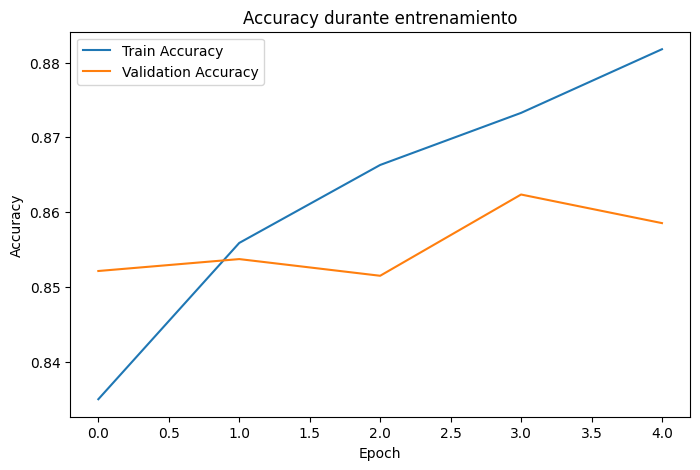

In [66]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy durante entrenamiento")
plt.legend()
plt.show()

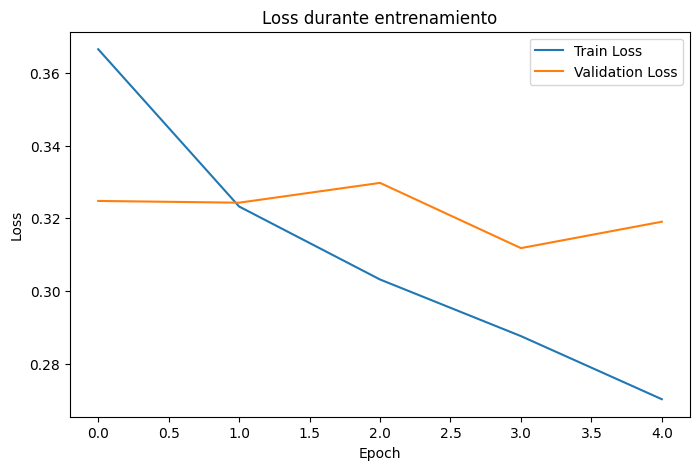

In [67]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss durante entrenamiento")
plt.legend()
plt.show()

<font size="6">Evaluacion</font>

In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [69]:
def get_predictions(model, dataloader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()

            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [70]:
y_true, y_pred, y_prob = get_predictions(model, test_loader, device)

print("Test Accuracy:", accuracy_score(y_true, y_pred))

Test Accuracy: 0.862796329339791


In [71]:
target_names = ["elliptical", "spiral"]

print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

  elliptical       0.84      0.80      0.82     12212
      spiral       0.88      0.90      0.89     19172

    accuracy                           0.86     31384
   macro avg       0.86      0.85      0.85     31384
weighted avg       0.86      0.86      0.86     31384



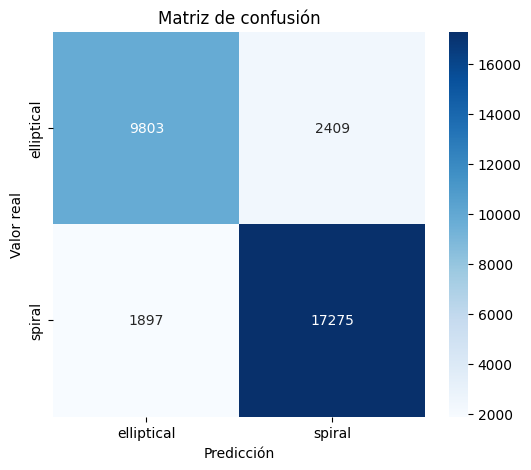

In [72]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.show()

In [73]:
test_results = test_df.reset_index(drop=True).copy()
test_results["y_true"] = y_true.astype(int)
test_results["y_pred"] = y_pred.astype(int)
test_results["y_prob"] = y_prob
test_results["correct"] = test_results["y_true"] == test_results["y_pred"]

test_results.head()

,image_path,label,label_id,y_true,y_pred,y_prob,correct
0,../data/images_gz2/images\19665.jpg,elliptical,0,0,0,0.041739,True
1,../data/images_gz2/images\79752.jpg,spiral,1,1,1,0.598902,True
2,../data/images_gz2/images\94681.jpg,spiral,1,1,1,0.872402,True
3,../data/images_gz2/images\33286.jpg,elliptical,0,0,0,0.187815,True
4,../data/images_gz2/images\4184.jpg,elliptical,0,0,0,0.168014,True


In [74]:
print(test_results["correct"].value_counts())

correct
True     27078
False     4306
Name: count, dtype: int64


In [75]:
class_names = {0: "elliptical", 1: "spiral"}

errors_df = test_results[test_results["correct"] == False].copy()
errors_df.head()

,image_path,label,label_id,y_true,y_pred,y_prob,correct
6,../data/images_gz2/images\4719.jpg,elliptical,0,0,1,0.895401,False
15,../data/images_gz2/images\176291.jpg,elliptical,0,0,1,0.831665,False
16,../data/images_gz2/images\111687.jpg,elliptical,0,0,1,0.718831,False
18,../data/images_gz2/images\164941.jpg,spiral,1,1,0,0.083814,False
24,../data/images_gz2/images\243132.jpg,spiral,1,1,0,0.332492,False


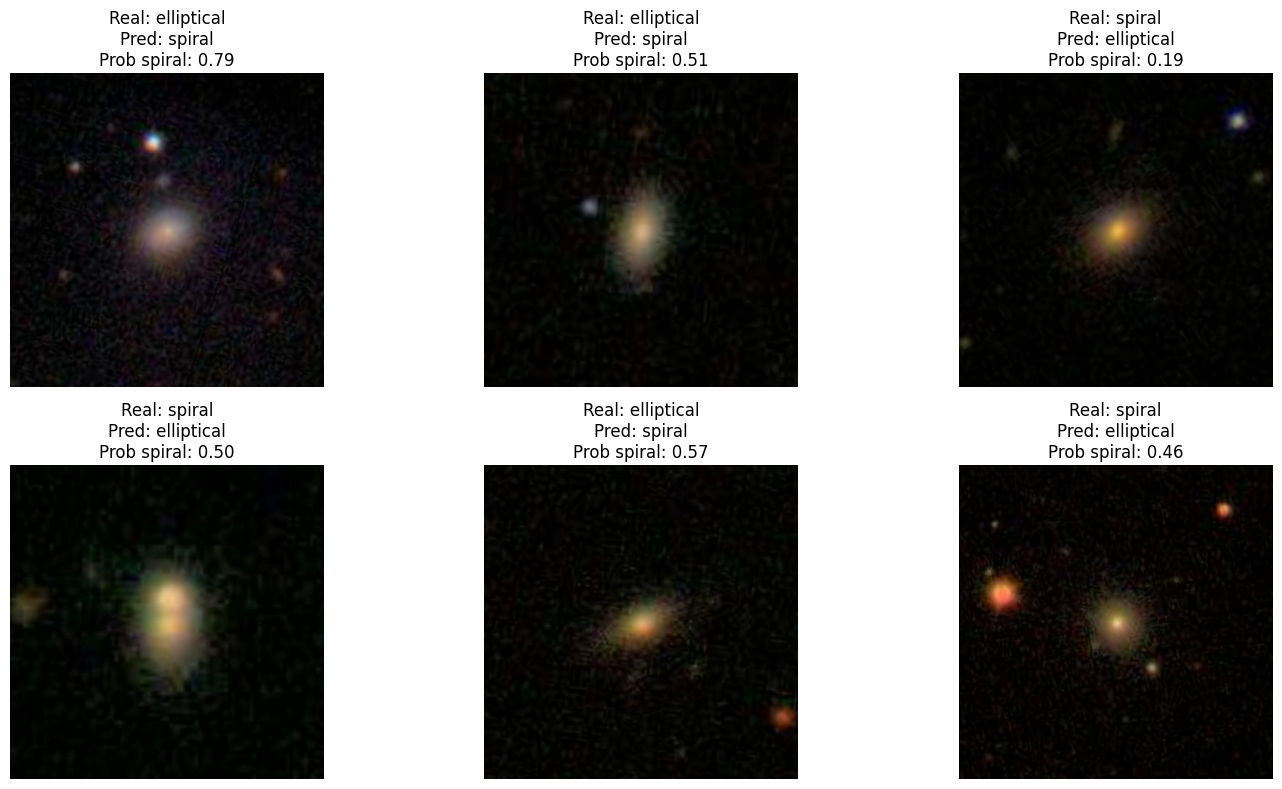

In [79]:
def show_misclassified_samples(df, n=6):
    sample_df = df.sample(min(n, len(df)), random_state=42)

    plt.figure(figsize=(15, 8))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        image = Image.open(row["image_path"]).convert("RGB")

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(
            f"Real: {class_names[row['y_true']]}\n"
            f"Pred: {class_names[row['y_pred']]}\n"
            f"Prob spiral: {row['y_prob']:.2f}"
        )

    plt.tight_layout()
    plt.show()

show_misclassified_samples(errors_df, n=6)

<font size="6">Interpretacion</font>

<font size="6">Conclusiones</font>